--- Part 3: 5-Fold Cross-Validation ---
λ: 0.0001  | Avg Val Error: 0.0368
λ: 0.001   | Avg Val Error: 0.0368
λ: 0.01    | Avg Val Error: 0.0368
λ: 0.1     | Avg Val Error: 0.0367
λ: 1       | Avg Val Error: 0.0383
λ: 10      | Avg Val Error: 0.0554


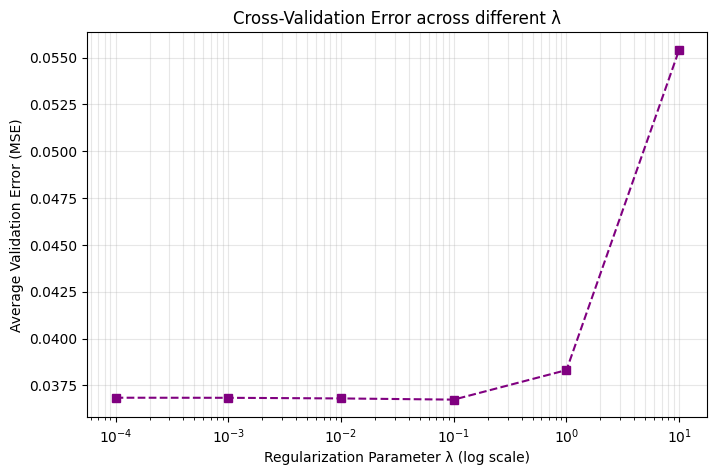


Best λ identified: 0.1
Final Test Error (on 30% split): 0.0415


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


# STEP 1: DATA SETUP 

# REQUIREMENT: Use a public/synthetic dataset
np.random.seed(42)
X = np.sort(5 * np.random.rand(200, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# REQUIREMENT: Split dataset (70% Train, 30% Test/Val)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.30, random_state=42)


# STEP 2: CROSS-VALIDATION LOGIC

# REQUIREMENT: λ values {10^−4, 10^−3, 10^−2, 10^−1, 1, 10}
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
avg_val_errors = []

# REQUIREMENT: Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
poly = PolynomialFeatures(degree=5) # Using degree 5 to see regularization effect

print("--- Part 3: 5-Fold Cross-Validation ---")
for l in lambdas:
    fold_errors = []
    
    for train_idx, val_idx in kf.split(X_train):
        # Create fold-specific training and validation sets
        X_f_train, X_f_val = X_train[train_idx], X_train[val_idx]
        y_f_train, y_f_val = y_train[train_idx], y_train[val_idx]
        
        # Train Ridge model
        model = Ridge(alpha=l)
        model.fit(poly.fit_transform(X_f_train), y_f_train)
        
        # REQUIREMENT: Compute validation error for this fold
        y_pred = model.predict(poly.transform(X_f_val))
        fold_errors.append(mean_squared_error(y_f_val, y_pred))
    
    # REQUIREMENT: Compute average validation error across all folds
    avg_error = np.mean(fold_errors)
    avg_val_errors.append(avg_error)
    print(f"λ: {l:<7} | Avg Val Error: {avg_error:.4f}")

# STEP 3: PLOTTING & FINAL EVALUATION



# REQUIREMENT: Plot validation error vs λ using logarithmic scale
plt.figure(figsize=(8, 5))
plt.plot(lambdas, avg_val_errors, marker='s', linestyle='--', color='purple')
plt.xscale('log') # Log scale requirement  
plt.xlabel("Regularization Parameter λ (log scale)")
plt.ylabel("Average Validation Error (MSE)")
plt.title("Cross-Validation Error across different λ")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# REQUIREMENT: Select best λ and retrain on the entire training set
best_lambda = lambdas[np.argmin(avg_val_errors)]
print(f"\nBest λ identified: {best_lambda}")

final_model = Ridge(alpha=best_lambda)
final_model.fit(poly.fit_transform(X_train), y_train)

# REQUIREMENT: Evaluate on test dataset and report error
test_error = mean_squared_error(y_val, final_model.predict(poly.transform(X_val)))
print(f"Final Test Error (on 30% split): {test_error:.4f}")